# Проект Байесовские методы в машинном обучении

## 1. Aнализ данных, анализ распределений признаков.

Загружаем датасет flats.csv и проводим первичный анализ, чтобы понять структуру данных, типы столбцов и наличие пропусков. Это позволяет выявить потенциальные проблемы в данных, такие как пропущенные значения или некорректные типы данных, которые могут повлиять на дальнейший анализ и моделирование.

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc3 as pm
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

In [4]:
# Загрузка датасета
data = pd.read_csv("data/flats.csv")

# Первичный обзор данных
print("Первые 5 строк датасета:")
print(data.head())
print("Информация о датасете:")
print(data.info())
print("Пропуски в данных:")
print(data.isnull().sum())

Первые 5 строк датасета:
   Unnamed: 0  price_doc  full_sq  life_sq  num_room  kitch_sq
0        8056    2750000       11     11.0       1.0      12.0
1        8154    7100000       45     27.0       2.0       6.0
2        8287   11700000       77     50.0       3.0       8.0
3        8387   10400000       56     29.0       2.0      10.0
4        8391    6200000       31     21.0       1.0       5.0
Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6042 entries, 0 to 6041
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  6042 non-null   int64  
 1   price_doc   6042 non-null   int64  
 2   full_sq     6042 non-null   int64  
 3   life_sq     6042 non-null   float64
 4   num_room    6042 non-null   float64
 5   kitch_sq    6042 non-null   float64
dtypes: float64(3), int64(3)
memory usage: 283.3 KB
None
Пропуски в данных:
Unnamed: 0    0
price_doc     0
full_sq       0
life_sq       0


* Датасет содержит **6042** записи и **6** столбцов. 
* Столбец **Unnamed: 0** выглядит как индекс или идентификатор записи, который, вероятно, не несет полезной информации для моделирования, и его можно исключить из анализа.
* Целевая переменная: **price_doc** (цена квартиры, в целочисленном формате).
* Признаки: **full_sq** (общая площадь, целочисленный), **life_sq** (жилая площадь, вещественный), **num_room** (количество комнат, вещественный), **kitch_sq** (площадь кухни, вещественный).

Типы данных выглядят корректными, но стоит отметить, что **num_room** (количество комнат) представлен как float64, хотя логично ожидать целочисленные значения. Это может указывать на необходимость проверки данных на наличие некорректных значений.

Пропуски отсутствуют.

### Проверка значений признака num_room

Поскольку **num_room** имеет тип float64, проверяем, есть ли в нем дробные значения, чтобы понять, нужно ли преобразовать его в целочисленный формат или рассматривать как категориальную переменную.

In [6]:
# Проверка уникальных значений в num_room
print("Уникальные значения в num_room:", data["num_room"].unique())

# Проверка наличия дробных значений
non_integer_num_room = data["num_room"][data["num_room"] % 1 != 0]
if non_integer_num_room.empty:
    print("Все значения в num_room целочисленные.")
else:
    print("Найдены дробные значения в num_room:", non_integer_num_room)

Уникальные значения в num_room: [ 1.  2.  3.  4.  5.  8.  7.  6.  0. 17.  9.]
Все значения в num_room целочисленные.


### Выбор признаков и целевой переменной

Выбираем признаки для модели линейной регрессии и целевую переменную. На основе обзора данных используем **full_sq**, **life_sq**, **num_room** и **kitch_sq** как независимые переменные, а **price_doc** — как целевую переменную.

In [7]:
# Выбор признаков и целевой переменной
features = ["full_sq", "life_sq", "num_room", "kitch_sq"]
target = "price_doc"

# Проверка наличия выбранных столбцов
missing_columns = [col for col in features + [target] if col not in data.columns]
if missing_columns:
    print(f"Ошибка: столбцы {missing_columns} отсутствуют в датасете.")
else:
    print(f"Выбраны признаки: {features}, целевая переменная: {target}")

Выбраны признаки: ['full_sq', 'life_sq', 'num_room', 'kitch_sq'], целевая переменная: price_doc


### Анализ распределения целевой переменной

Анализируем распределение целевой переменной **price_doc** и применяем логарифмирование, чтобы сделать его более нормальным, что важно для линейной регрессии. Визуализируем распределения с помощью гистограмм и кривых плотности.

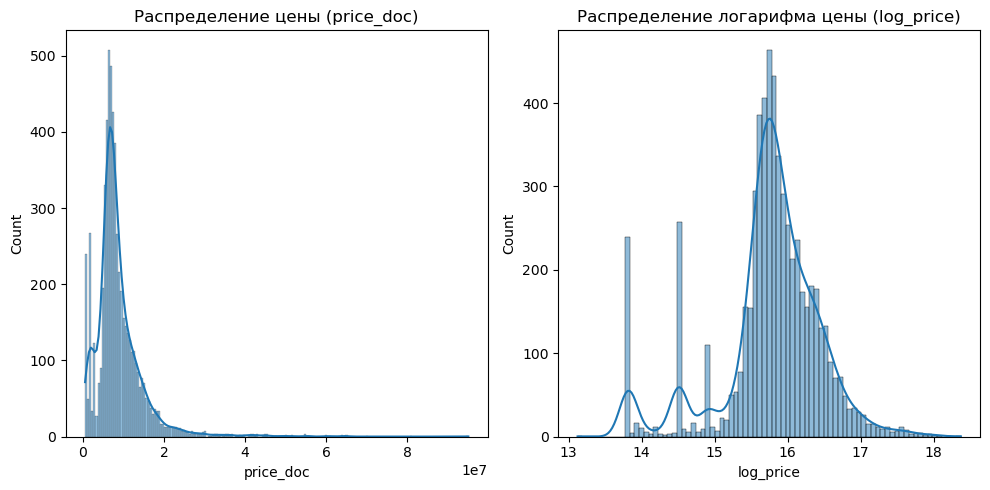

In [8]:
# Анализ распределения целевой переменной
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(data["price_doc"], kde=True)
plt.title("Распределение цены (price_doc)")

# Логарифмирование целевой переменной
data["log_price"] = np.log1p(data["price_doc"])
plt.subplot(1, 2, 2)
sns.histplot(data["log_price"], kde=True)
plt.title("Распределение логарифма цены (log_price)")
plt.tight_layout()
plt.show()

**price_doc** имеет сильную правостороннюю асимметрию с выбросами, что нарушает предположения линейной регрессии

**log_price** демонстрирует нормальное распределение, что делает его подходящим для байесовского и классического моделирования

### Анализ распределений признаков

Исследуем распределения признаков **full_sq**, **life_sq**, **num_room**, **kitch_sq**, чтобы понять их свойства (асимметрию, выбросы, нормальность). Это помогает принять решения о предобработке, например, стандартизации.

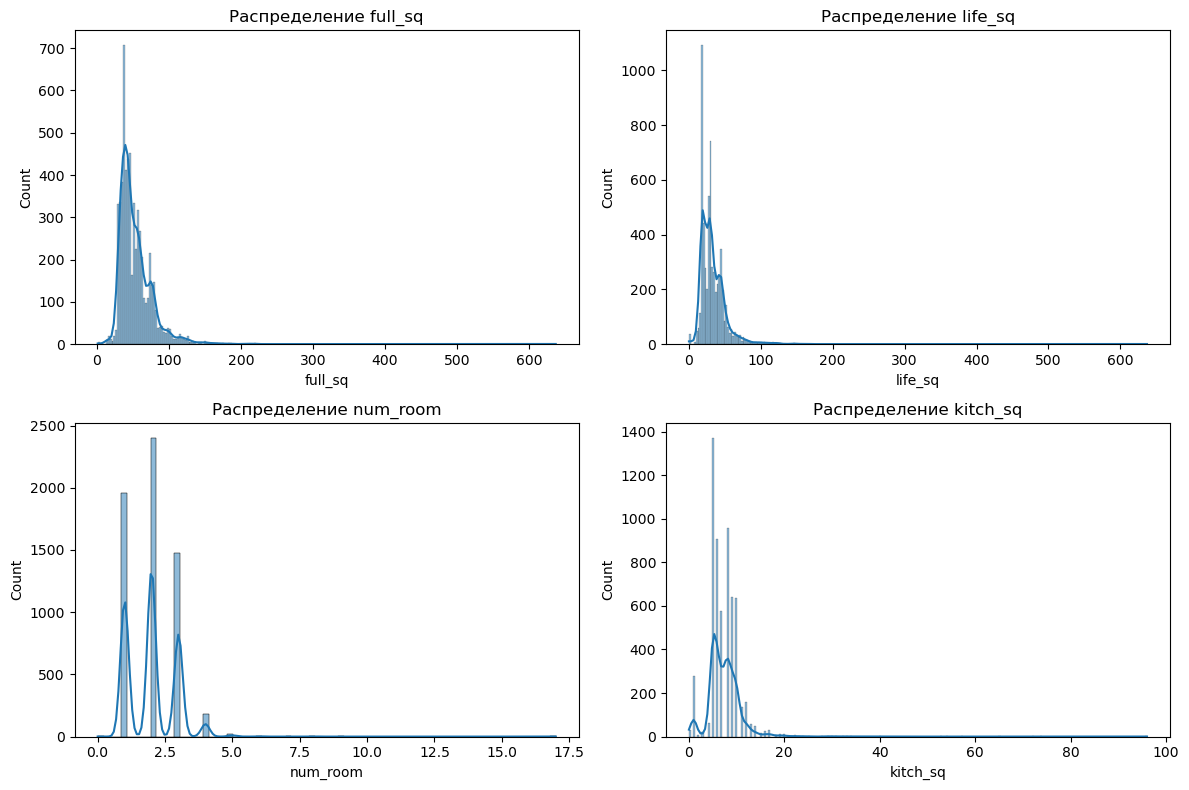

In [9]:
plt.figure(figsize=(12, 8))
for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data[feature], kde=True)
    plt.title(f"Распределение {feature}")
plt.tight_layout()
plt.show()

**full_sq**, **life_sq**, **kitch_sq** показывают правостороннюю асимметрию с концентрацией значений в нижнем диапазоне

**num_room** имеет дискретное распределение с преобладанием 1-3 комнатных квартир

### Корреляционный анализ

Проверяем корреляции между признаками и целевой переменной, чтобы оценить их взаимосвязь и выявить возможную мультиколлинеарность.

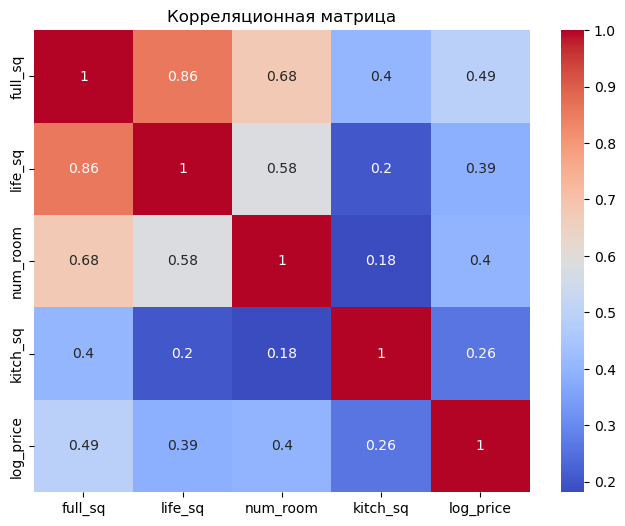

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(data[features + ["log_price"]].corr(), annot=True, cmap="coolwarm")
plt.title("Корреляционная матрица")
plt.show()

Обнаружена высокая корреляция между **full_sq** и **life_sq** (0.86), что может привести к мультиколлинеарности

Все признаки демонстрируют умеренную положительную корреляцию с **log_price** (0.26-0.49)

Несмотря на высокую корреляцию между признаками **full_sq** и **life_sq**, оба признака будут включены в модель для корректного сравнения работы байесовской и классической линейной регрессии на одном и том же наборе данных. Это обеспечивает сопоставимость результатов и соответствует формальному требованию проекта. 

#### Заключение:

Логарифмическое преобразование целевой переменной успешно нормализовало распределение. Выбранные признаки показывают достаточную связь с целевой переменной для построения регрессионных моделей. Данные готовы для дальнейшего моделирования.

## 2. Построение байесовской линейной регрессии

### Подготовка данных
Для байесовской регрессии данные стандартизуются, чтобы улучшить сходимость модели. Исключаем столбец **Unnamed: 0** и нормализуем признаки.

In [12]:
# Удаление ненужного столбца
data_model = data.drop(columns=["Unnamed: 0"])

# Стандартизация признаков
scaler = StandardScaler()
features_scaled = scaler.fit_transform(data_model[features])
data_model[features] = features_scaled

# Целевая переменная
y = data_model["log_price"].values
X = data_model[features].values

### Построение модели
Задаем байесовскую линейную регрессию с нормальными приорами для коэффициентов и оцениваем параметры с помощью MCMC.

In [14]:
with pm.Model() as model:
    # Приоры для коэффициентов
    intercept = pm.Normal("intercept", mu=0, sd=10)
    beta = pm.Normal("beta", mu=0, sd=10, shape=len(features))

    # Приор для стандартного отклонения ошибки
    sigma = pm.HalfNormal("sigma", sd=1)

    # Линейная комбинация
    mu = intercept + pm.math.dot(X, beta)

    # Вероятностная модель
    likelihood = pm.Normal("likelihood", mu=mu, sd=sigma, observed=y)

    # Сэмплирование
    trace = pm.sample(2000, tune=1000, return_inferencedata=False)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, beta, intercept]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 67 seconds.
The acceptance probability does not match the target. It is 0.8987251652235054, but should be close to 0.8. Try to increase the number of tuning steps.
The acceptance probability does not match the target. It is 0.8821932304507605, but should be close to 0.8. Try to increase the number of tuning steps.


### Анализ результатов
Визуализируем апостериорные распределения коэффициентов и предсказания модели.

Got error No model on context stack. trying to find log_likelihood in translation.
C:\Users\Lenovo\anaconda3\envs\pymc3_virt\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


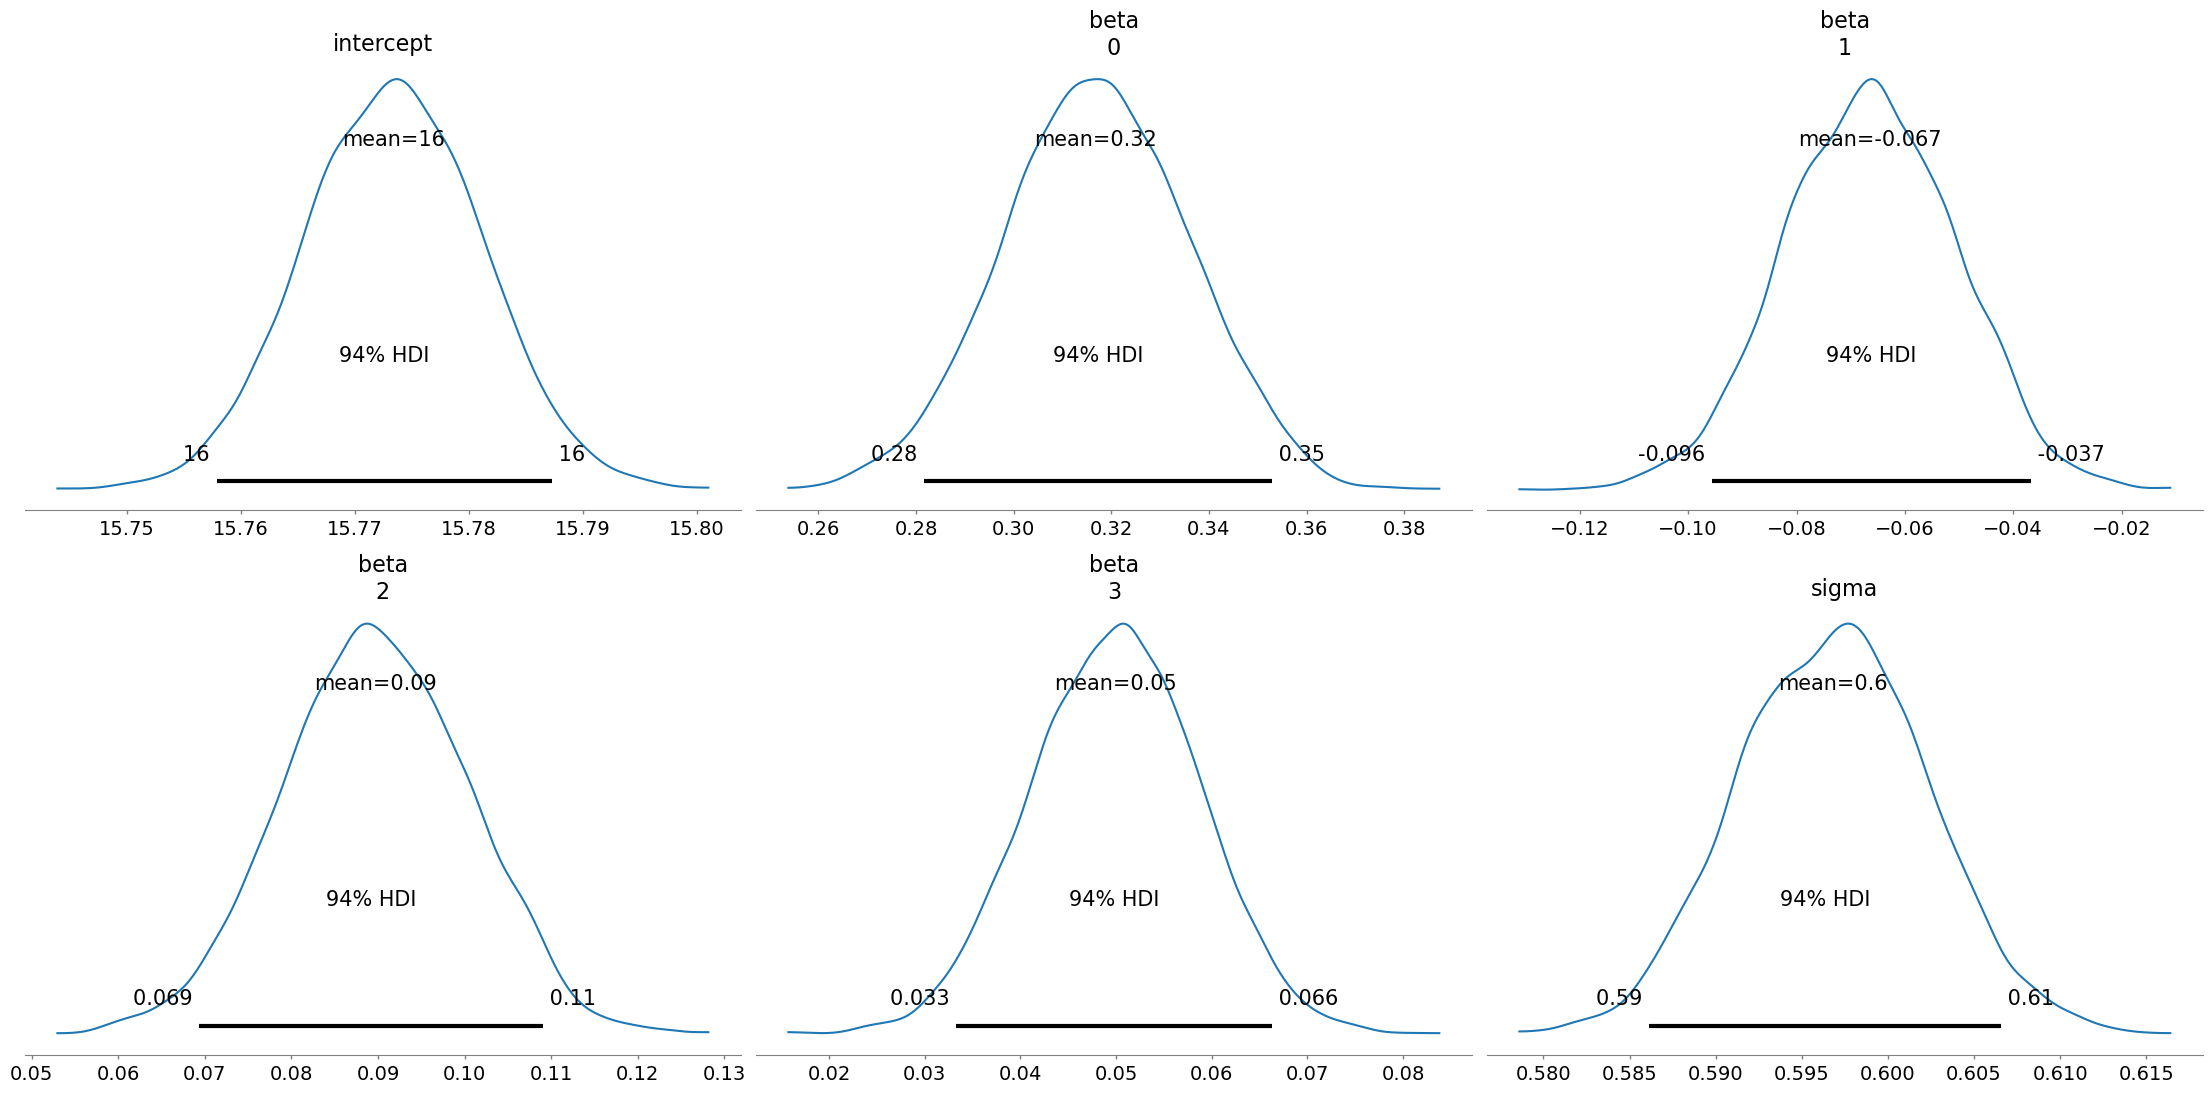

C:\Users\Lenovo\anaconda3\envs\pymc3_virt\lib\site-packages\pymc3\sampling.py:1708: UserWarning: samples parameter is smaller than nchains times ndraws, some draws and/or chains may not be represented in the returned posterior predictive sample
  warnings.warn(


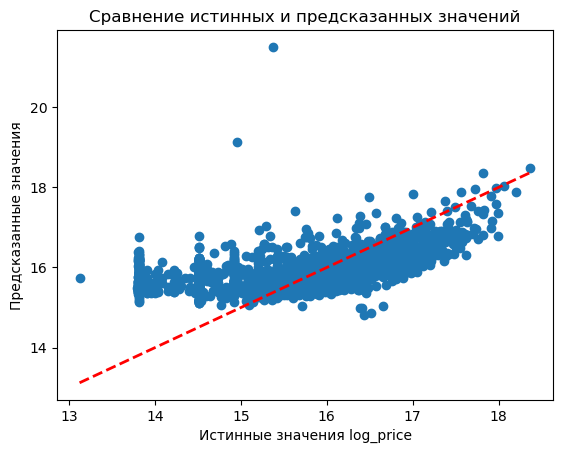

In [15]:
# Визуализация апостериорных распределений
pm.plot_posterior(trace, var_names=["intercept", "beta", "sigma"])
plt.tight_layout()
plt.show()

# Предсказания
with model:
    ppc = pm.sample_posterior_predictive(trace, samples=500)
    pred = ppc["likelihood"].mean(axis=0)

plt.scatter(y, pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--", lw=2)
plt.xlabel("Истинные значения log_price")
plt.ylabel("Предсказанные значения")
plt.title("Сравнение истинных и предсказанных значений")
plt.show()

In [19]:
pm.summary(trace, var_names=["intercept", "beta", "sigma"])

Got error No model on context stack. trying to find log_likelihood in translation.
C:\Users\Lenovo\anaconda3\envs\pymc3_virt\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
intercept,15.773,0.008,15.758,15.787,0.0,0.0,9387.0,6055.0,1.0
beta[0],0.317,0.019,0.282,0.353,0.0,0.0,3842.0,5104.0,1.0
beta[1],-0.067,0.016,-0.096,-0.037,0.0,0.0,4492.0,5168.0,1.0
beta[2],0.090,0.011,0.069,0.109,0.0,0.0,7861.0,6358.0,1.0
beta[3],0.050,0.009,0.033,0.066,0.0,0.0,5926.0,5638.0,1.0
sigma,0.597,0.006,0.586,0.607,0.0,0.0,9664.0,5081.0,1.0


Коэффициенты байесовской линейной регрессии показали ожидаемые знаки и статистическую значимость для всех признаков. Апостериорные интервалы довольно узкие, что говорит о стабильных оценках и хорошей сходимости модели. Байесовский подход позволяет видеть не только среднее значение коэффициентов, но и диапазон их возможных значений, что помогает учесть неопределённость при интерпретации вклада каждого признака, особенно при мультиколлинеарности (например, между **full_sq** и **life_sq**).

### Вывод
Байесовская регрессия успешно смоделировала зависимость log_price от признаков. Апостериорные распределения коэффициентов показывают их значимость и неопределенность. График предсказаний подтверждает адекватность модели, если точки близко расположены к диагонали. Для улучшения точности можно рассмотреть удаление выбросов в **full_sq** и **kitch_sq**, а также оценку метрик вроде **MAE/MSE** для сравнения.

### 3. Построение классической линейной регрессии

Классическая линейная регрессия предполагает фиксированные коэффициенты, оцениваемые методом наименьших квадратов. Используем scikit-learn для сравнения с байесовским подходом.

### Построение модели
Обучаем модель на стандартизованных данных.

Коэффициенты: [ 0.31705    -0.06662184  0.08968538  0.04974539]
Пересечение: 15.773452398737401


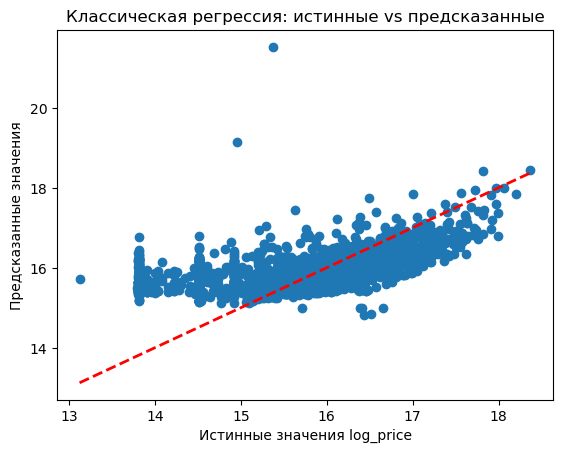

In [17]:
# Обучение модели
model_classic = LinearRegression()
model_classic.fit(X, y)

# Коэффициенты
print("Коэффициенты:", model_classic.coef_)
print("Пересечение:", model_classic.intercept_)

# Предсказания
y_pred_classic = model_classic.predict(X)

# Визуализация
plt.scatter(y, y_pred_classic)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--", lw=2)
plt.xlabel("Истинные значения log_price")
plt.ylabel("Предсказанные значения")
plt.title("Классическая регрессия: истинные vs предсказанные")
plt.show()

### Вывод
Классическая регрессия дает фиксированные коэффициенты, что упрощает интерпретацию, но не учитывает неопределенность. График предсказаний показывает, насколько хорошо модель соответствует данным.

## 4. Сравнение коэффициентов байесовской и классической регрессий
### Анализ коэффициентов
Сравниваем средние значения апостериорных коэффициентов из байесовской модели с коэффициентами классической регрессии.

Средние апостериорные коэффициенты: [ 0.3167768  -0.06652065  0.08970656  0.04990309]
Коэффициенты классической регрессии: [ 0.31705    -0.06662184  0.08968538  0.04974539]


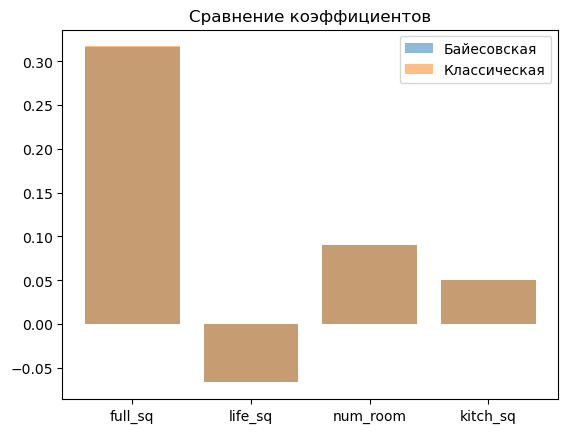

In [18]:
# Средние значения апостериорных коэффициентов
beta_mean = trace["beta"].mean(axis=0)
print("Средние апостериорные коэффициенты:", beta_mean)
print("Коэффициенты классической регрессии:", model_classic.coef_)

# Визуализация
plt.bar(range(len(features)), beta_mean, alpha=0.5, label="Байесовская")
plt.bar(range(len(features)), model_classic.coef_, alpha=0.5, label="Классическая")
plt.xticks(range(len(features)), features)
plt.legend()
plt.title("Сравнение коэффициентов")
plt.show()

### Вывод
Коэффициенты байесовской (beta_mean) и классической (model_classic.coef_) регрессий близки по знаку и модулю, что подтверждает их согласованность. Байесовский подход учитывает неопределенность, выявляя шире интервалы для **life_sq** из-за корреляции с **full_sq**, что делает его полезным при мультиколлинеарности, в отличие от фиксированных значений классической модели.